# Random Forest From Scratch

## 1. Modelando RandomForest com NumPy

In [2]:
from DecisionTree import DecisionTree
from collections import Counter
import numpy as np

class RandomForest:
    def __init__(self, n_estimators=10,*,max_depth=10, min_samples_split=2, n_features=None):
        self.n_estimators=n_estimators
        self.max_depth=max_depth
        self.min_samples_split=min_samples_split
        self.n_features=n_features
        self.trees = []

    def fit(self, X, y):
        for _ in range(self.n_estimators):
            #faz bootstrap no dataset em loop 
            boot_idxs = np.random.choice(X.shape[0], X.shape[0],  replace=True)
            X_boot, y_boot = X[boot_idxs], y[boot_idxs]

            #treina arvoree com esse bootstrap
            tree_clf = DecisionTree(max_depth=self.max_depth, min_sample_split=self.min_samples_split, n_features=self.n_features)

            tree_clf.fit(X_boot,y_boot)

            #guando no modelo
            self.trees.append(tree_clf)
        return self


    def predict(self, X):

        #loop para todas as arvores novamente
        predictions = [tree.predict(X) for tree in self.trees]

        #transpor a matriz
        predictions = np.array(predictions).T

        #calcular predict para linha
        final_predicts = np.array([
            self._most_common_label(predict) 
            for predict in predictions]).flatten()
        
        return final_predicts

    
    def _most_common_label(self, y):
        counter = Counter(y)
        value = counter.most_common(1)[0][0]
        return value

## 2. Modelando com Scikit-Learn e From Scratch

In [3]:
from sklearn.ensemble import RandomForestClassifier

#modelo do sklearn
sk_rf_clf = RandomForestClassifier()

#modelo com numpy
scratch_rf_clf = RandomForest()

## 3. Carregando dados e Treinando os modelos

In [7]:
from src.data_loading import load_data

X_train, X_test, y_train, y_test = load_data()

'''Treinando os modelos para comparar'''
sk_rf_clf.fit(X_train, y_train)
scratch_rf_clf.fit(X_train, y_train)


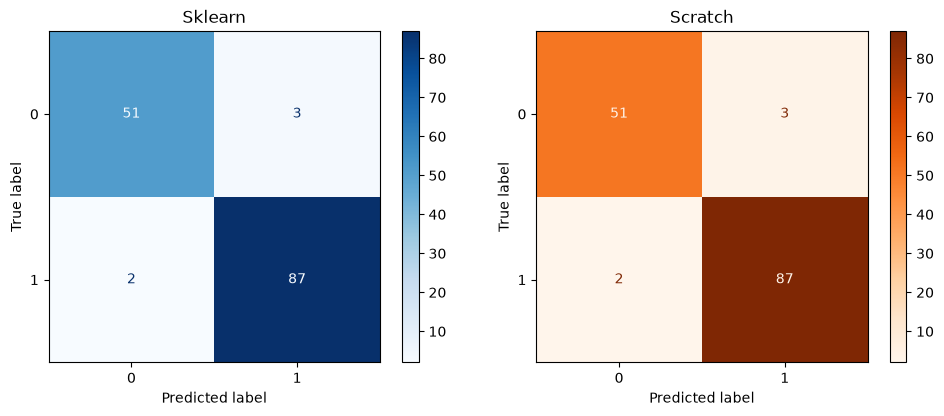

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix


cm_sk = confusion_matrix(y_test, sk_rf_clf.predict(X_test))
cm_scratch = confusion_matrix(y_test, scratch_rf_clf.predict(X_test))


fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay(cm_sk).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Sklearn')

ConfusionMatrixDisplay(cm_scratch).plot(ax=axes[1], cmap='Oranges')
axes[1].set_title('Scratch')

plt.tight_layout()
plt.show()

## 4. Visualizando a diferença de acurrácia

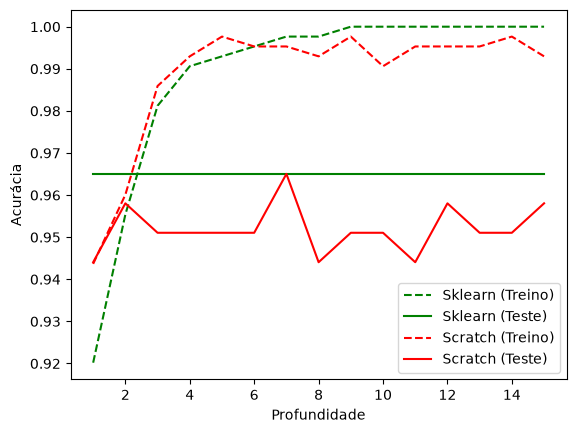

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

depths = range(1, 16)
sk_train, sk_test = [], []
sc_train, sc_test = [], []

for d in depths:
    # Sklearn
    sk = RandomForestClassifier(max_depth=d, random_state=42).fit(X_train, y_train)
    sk_train.append(sk.score(X_train, y_train))
    sk_test.append(sk.score(X_test, y_test))
    
    # Scratch
    sc = RandomForest(max_depth=d)
    sc.fit(X_train, y_train)
    sc_train.append(accuracy_score(y_train, sc.predict(X_train)))
    sc_test.append(accuracy_score(y_test, sc.predict(X_test)))

plt.plot(depths, sk_train, 'g--', label='Sklearn (Treino)')
plt.plot(depths, sk_test, 'g-', label='Sklearn (Teste)')
plt.plot(depths, sc_train, 'r--', label='Scratch (Treino)')
plt.plot(depths, sc_test, 'r-', label='Scratch (Teste)')

plt.xlabel('Profundidade')
plt.ylabel('Acurácia')
plt.legend()
plt.show()